# Latent Space Visualization with AutoEncoders

Online Visualization:
- https://introduction-to-autoencoders.vercel.app/

## 1 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, TensorDataset

---

# 2 Load MNIST CSV Dataset

Your CSV format:

In [2]:
df = pd.read_csv("mnist_train.csv")

print(df.shape)
df.head()

(6000, 785)


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


---

# 3 Prepare Data

Separate **labels** and **image pixels**.

In [3]:
labels = df["label"].values

X = df.drop(columns=["label"]).values
X = X.astype(np.float32)

# normalize pixels
X = X / 255.0

print(X.shape)

(6000, 784)


---

# 4 Visualize Some Digits

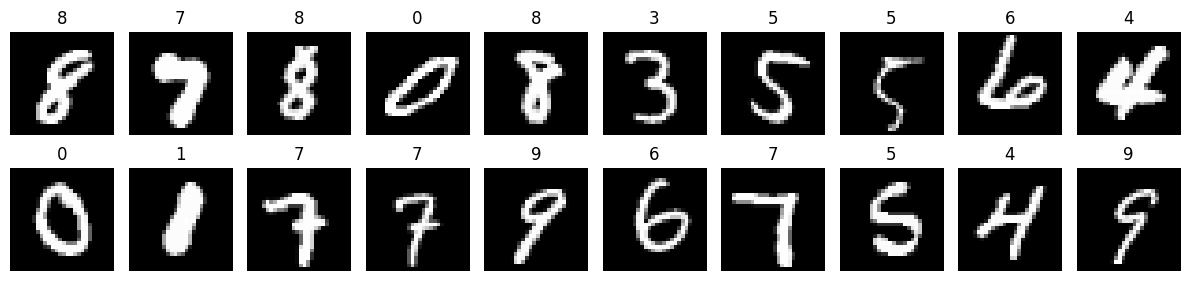

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(12, 3))

for i in range(20):
    
    img = X[i].reshape(28, 28)

    ax = axes[i//10, i%10]
    ax.imshow(img, cmap="gray")
    ax.set_title(labels[i])
    ax.axis("off")

plt.tight_layout()
plt.show()

---

# 5 Create PyTorch Dataset

In [5]:
X_tensor = torch.tensor(X)
dataset = TensorDataset(X_tensor)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

---

# 6 Define AutoEncoder

The **bottleneck layer** forces the network to learn a **compressed representation**.

Latent dimension = **16**

In [6]:
class AutoEncoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 16)
        )

        self.decoder = nn.Sequential(
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):

        z = self.encoder(x)
        x_hat = self.decoder(z)

        return x_hat

---

# 7 Initialize Model

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoEncoder().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

---

# 8 Train AutoEncoder

In [8]:
epochs = 500

for epoch in range(epochs):

    total_loss = 0

    for (x,) in loader:

        x = x.to(device)

        optimizer.zero_grad()

        recon = model(x)

        loss = criterion(recon, x)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:02d} | Loss {total_loss:.4f}")

Epoch 50 | Loss 0.7080
Epoch 100 | Loss 0.5059
Epoch 150 | Loss 0.4301
Epoch 200 | Loss 0.3887
Epoch 250 | Loss 0.3618
Epoch 300 | Loss 0.3444
Epoch 350 | Loss 0.3302
Epoch 400 | Loss 0.3167
Epoch 450 | Loss 0.3069
Epoch 500 | Loss 0.2995


---

# 9 Visualize Reconstruction

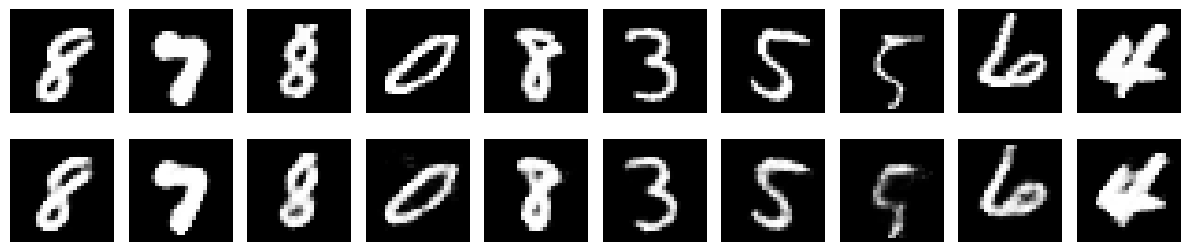

In [9]:
with torch.no_grad():

    sample = X_tensor[:10].to(device)

    recon = model(sample)

    recon = recon.cpu().numpy()

fig, axes = plt.subplots(2, 10, figsize=(12, 3))

for i in range(10):

    axes[0, i].imshow(X[i].reshape(28,28), cmap="gray")
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i].reshape(28,28), cmap="gray")
    axes[1, i].axis("off")

axes[0,0].set_ylabel("Original", fontsize=12)
axes[1,0].set_ylabel("Reconstruction", fontsize=12)

plt.tight_layout()
plt.show()

---

# 10 Extract Latent Representations

We now pass all images through the **encoder only**.

In [10]:
model.eval()

with torch.no_grad():

    latent = model.encoder(X_tensor.to(device))

latent = latent.cpu().numpy()

print(latent.shape)

(6000, 16)


Each digit is now represented by **16 learned features**.

---

# 11 PCA Visualization

In [11]:
pca = PCA(n_components=2)

z_pca = pca.fit_transform(latent)

---

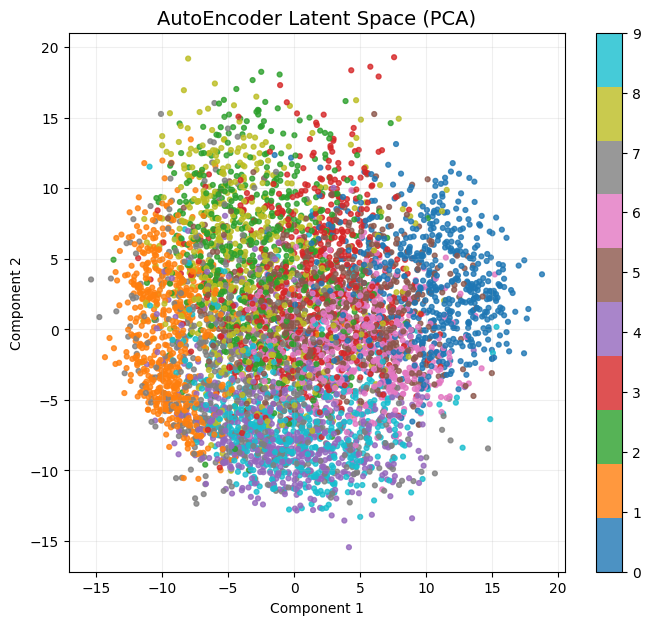

In [12]:
plt.figure(figsize=(8,7))

scatter = plt.scatter(
    z_pca[:,0],
    z_pca[:,1],
    c=labels,
    cmap="tab10",
    s=12,
    alpha=0.8
)

plt.colorbar(scatter)

plt.title("AutoEncoder Latent Space (PCA)", fontsize=14)
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.grid(alpha=0.2)

plt.show()

---

# 12 t-SNE Visualization

In [13]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

z_tsne = tsne.fit_transform(latent)

---

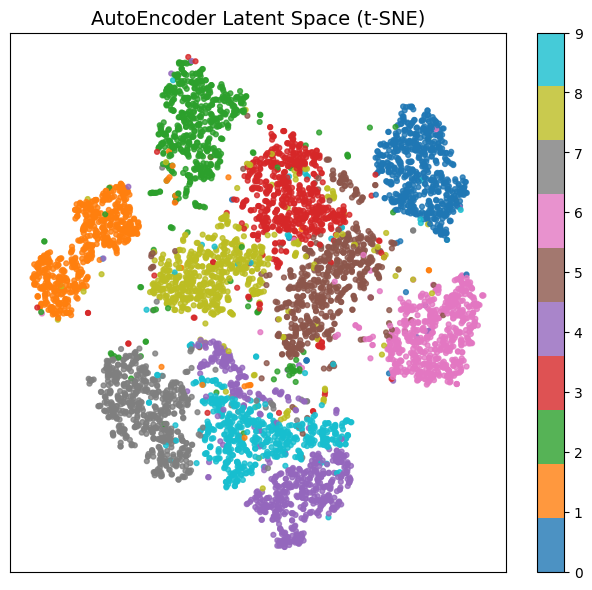

In [14]:
plt.figure(figsize=(8,7))

scatter = plt.scatter(
    z_tsne[:,0],
    z_tsne[:,1],
    c=labels,
    cmap="tab10",
    s=12,
    alpha=0.8
)

plt.colorbar(scatter)

plt.title("AutoEncoder Latent Space (t-SNE)", fontsize=14)

plt.xticks([])
plt.yticks([])

plt.show()